In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import sys
import pyabc
import seaborn as sns

import healpy as hp
from scipy.special import sph_harm
import fitsio
import skyproj
from astropy.coordinates import SkyCoord, Angle
import astropy.units as u

sys.path.insert(0, '/home/aew492/lss-dipoles/code')
import tools
import dipole
import multipoles
import generate_mocks as gm

## quasar healpix map construction

In [3]:
blim = 30
nside_hi = 64
resdir = '/scratch/aew492/lss-dipoles_results/results'

### small masks

In [15]:
small_masks = fitsio.read(f'../data/masks/mask_master_hpx_r1.0.fits')

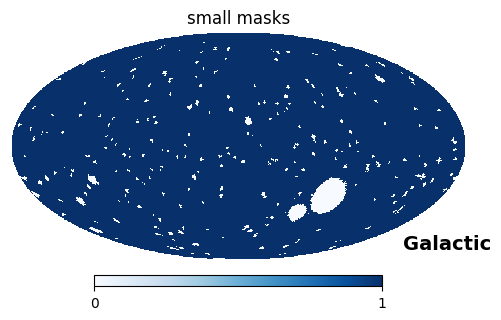

In [17]:
fig = plt.figure(figsize=(6,3))
hp.mollview(small_masks, coord=['C','G'], cmap='Blues', title='small masks', fig=fig)

### Quaia G20.0

In [4]:
# load FITS catalog as a healpy map
qmap = tools.load_catalog_as_map(f'../data/catalogs/quaia/quaia_G20.0.fits', frame='icrs', nside=nside_hi)

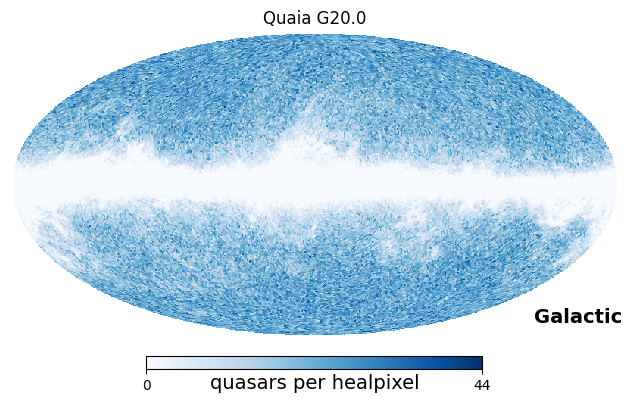

In [13]:
fig = plt.figure(figsize=(7,4))
hp.mollview(qmap, coord=['C','G'], cmap='Blues', title='Quaia G20.0', unit='quasars per healpixel', fig=fig)

In [18]:
# mask the galactic plane and apply small masks 
qmap_masked = qmap * small_masks * tools.get_galactic_plane_mask(blim, nside=nside_hi, frame='icrs')

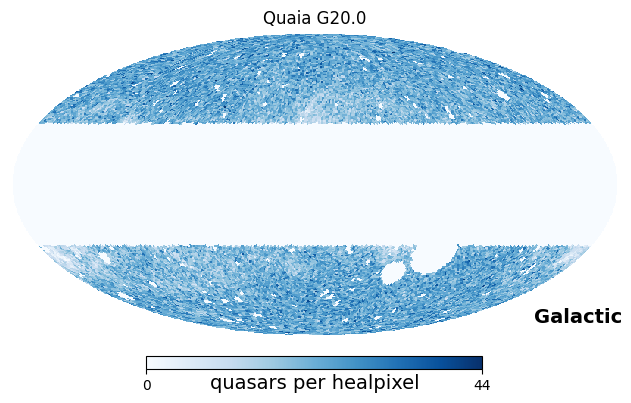

In [19]:
fig = plt.figure(figsize=(7,4))
hp.mollview(qmap_masked, coord=['C','G'], cmap='Blues', title='Quaia G20.0', unit='quasars per healpixel', fig=fig)

In [21]:
# save
np.save(f'../data/catalogs/quaia/quaia_G20.0_masked.npy', qmap_masked)

### Quaia G20.5

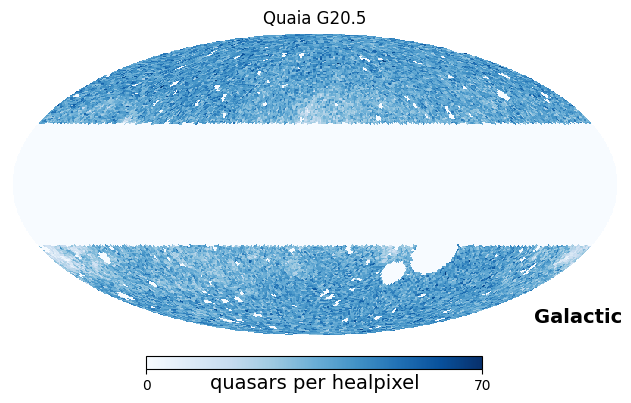

In [22]:
# load FITS catalog as a healpy map
qmap = tools.load_catalog_as_map(f'../data/catalogs/quaia/quaia_G20.5.fits', frame='icrs', nside=nside_hi)
# mask the galactic plane and apply small masks 
qmap_masked = qmap * small_masks * tools.get_galactic_plane_mask(blim, nside=nside_hi, frame='icrs')
# plot
fig = plt.figure(figsize=(7,4))
hp.mollview(qmap_masked, coord=['C','G'], cmap='Blues', title='Quaia G20.5', unit='quasars per healpixel', fig=fig)

In [23]:
# save
np.save(f'../data/catalogs/quaia/quaia_G20.5_masked.npy', qmap_masked)

### Quaia G20.0 zsplits

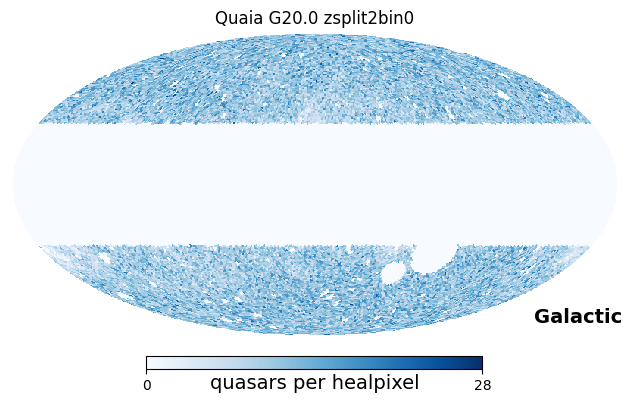

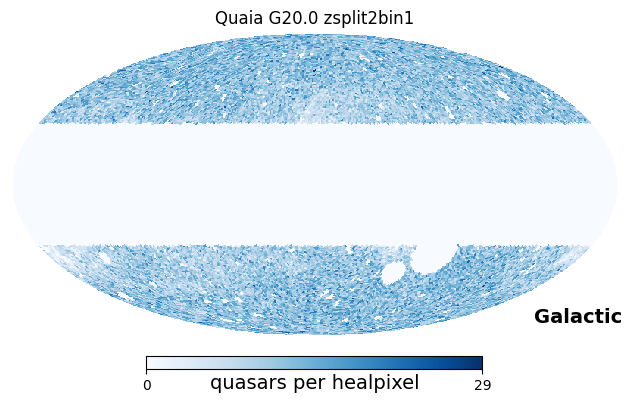

In [26]:
for zbin in [0, 1]:
    # load FITS catalog as a healpy map
    qmap = tools.load_catalog_as_map(f'../data/catalogs/quaia/quaia_G20.0_zsplit2bin{zbin}.fits', frame='icrs', nside=nside_hi)
    # mask the galactic plane and apply small masks 
    qmap_masked = qmap * small_masks * tools.get_galactic_plane_mask(blim, nside=nside_hi, frame='icrs')
    # plot
    fig = plt.figure(figsize=(7,4))
    hp.mollview(qmap_masked, coord=['C','G'], cmap='Blues', title=f'Quaia G20.0 zsplit2bin{zbin}', unit='quasars per healpixel', fig=fig)

    # save
    np.save(f'../data/catalogs/quaia/quaia_G20.0_zsplit2bin{zbin}_masked.npy', qmap_masked)

### CatWISE

In [43]:
# load FITS catalog as a healpy map
qmap = tools.load_catalog_as_map(f'../data/catalogs/catwise_agns/catwise_agns_master.fits', frame='icrs', nside=nside_hi)

In [44]:
# check that this catalog includes the correct W1 cut
from astropy.table import Table
cat = Table.read(f'../data/catalogs/catwise_agns/catwise_agns_master.fits', format='fits')
print(f"max W1 is {np.max(cat['w1']):.2f}")

max W1 is 16.40


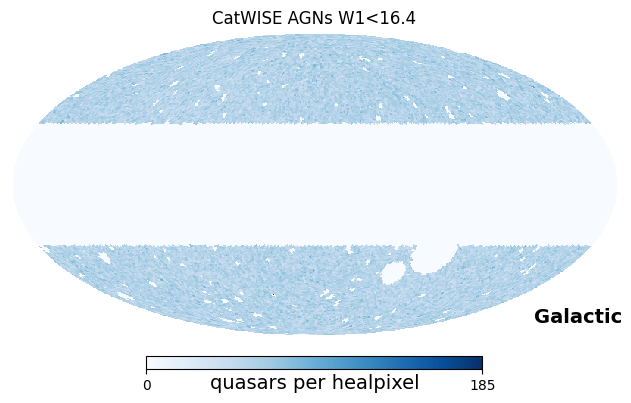

In [45]:
# mask the galactic plane and apply small masks 
qmap_masked = qmap * small_masks * tools.get_galactic_plane_mask(blim, nside=nside_hi, frame='icrs')
# plot
fig = plt.figure(figsize=(7,4))
hp.mollview(qmap_masked, coord=['C','G'], cmap='Blues', title='CatWISE AGNs W1<16.4', unit='quasars per healpixel', fig=fig)

In [46]:
# save
np.save(f'../data/catalogs/catwise_agns/catwise_agns_masked.npy', qmap_masked)